# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Assika Latifah Mercyana]
- **Email:** [assikamercyana@gmail.com]
- **ID Dicoding:** [CDCC229D6X2230]

## Menentukan Pertanyaan Bisnis

- Bagaimana tren pertumbuhan jumlah transaksi dan total pendapatan bulanan pada platform e-commerce selama periode 2016–2018, serta kapan terjadi puncak performa penjualan?
- Kategori produk apa yang memberikan kontribusi pendapatan terbesar setiap bulan, dan bagaimana pola musiman penjualannya selama periode 2016–2018?

## Import Semua Packages/Library yang Digunakan
Pada bagian ini, dilakukan import beberapa library yang akan digunakan selama proses analisis. Pandas digunakan untuk mengolah data, numpy untuk perhitungan angka, serta matplotlib dan seaborn untuk membuat visualisasi. Selain itu, digunakan juga display agar tampilan data lebih rapi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## Data Wrangling


### Gathering Data
Pada tahap ini dilakukan proses pengumpulan data (gathering data) dengan mengakses dataset yang tersimpan di Google Drive. Proses mounting Google Drive bertujuan agar file dapat diakses melalui lingkungan kerja.

In [2]:
# Load dataset dari Google Drive
from google.colab import drive
drive.mount('/content/drive')

orders = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/orders_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/order_items_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/products_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/customers_dataset.csv')

Mounted at /content/drive


**Insight:**
- Dataset berhasil diakses dan dimuat dari Google Drive ke dalam Google Colab tanpa kendala
- Data utama yang digunakan terdiri dari beberapa tabel, yaitu orders, order_items, products, dan customers
- Data telah siap digunakan untuk tahap analisis selanjutnya

### Assessing Data
Pada tahap ini dilakukan pengecekan data untuk mengetahui kondisi dataset, seperti tipe data, nilai yang hilang, dan gambaran umum data. Hal ini dilakukan agar data siap digunakan untuk proses analisis selanjutnya.

In [3]:
# Menampilkan 5 baris pertama dari DataFrame
display(orders.head())
display(order_items.head())
display(products.head())
display(customers.head())

# Cek info data (tipe data & missing value)
orders.info()
order_items.info()
products.info()
customers.info()

# Statistik data
display(orders.describe())
display(order_items.describe())
display(products.describe())
display(customers.describe())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


 **Insight:**
- Dataset utama yang digunakan terdiri dari empat tabel data, yaitu orders (99.441), order_items (112.650), products (32.951), dan customers (99.441).
- Dataset orders memiliki missing values pada atribut order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date.
- Dataset products juga memiliki missing values pada semua atribut kecuali product_id yang perlu ditangani.
- Dataset order_items dan customers tidak mengandung missing values.
- Beberapa kolom yang merepresentasikan waktu pada dataset orders dan order_items masih bertipe object, sehingga perlu dilakukan konversi ke tipe datetime agar dapat digunakan dalam analisis berbasis waktu.
- Dataset order_items dapat digunakan langsung untuk analisis harga dan jumlah penjualan.
- Dataset customers memuat informasi lokasi seperti customer_city dan customer_state yang dapat digunakan untuk analisis geografis.

### Cleaning Data
Pada tahap ini dilakukan pembersihan data dengan mengecek dan menangani missing values, perbaikan tipe data, dan penghapusan data duplikat.

In [4]:
# Cek Missing Values
print("=== MISSING VALUES ===")
print("\nOrders:\n", orders.isnull().sum())
print("\nOrder Items:\n", order_items.isnull().sum())
print("\nProducts:\n", products.isnull().sum())
print("\nCustomers:\n", customers.isnull().sum())

# Cek Duplikat Data
print("\n=== DUPLIKAT DATA ===")
print("Jumlah duplikasi orders: ", orders.duplicated().sum())
print("Jumlah duplikasi order_items: ", order_items.duplicated().sum())
print("Jumlah duplikasi products: ", products.duplicated().sum())
print("Jumlah duplikasi customers: ", customers.duplicated().sum())

=== MISSING VALUES ===

Orders:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order Items:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Customers:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city

**Insight:**
- Dataset orders memiliki missing values pada beberapa kolom waktu, yaitu, order_approved_at (160), order_delivered_carrier_date (1.783), dan  order_delivered_customer_date (2.965) yang menunjukkan bahwa terdapat pesanan yang belum diproses, belum dikirim, atau belum sampai ke pelanggan.
- Dataset order_items dan customers tidak memiliki missing values, siap digunakan untuk analisis lebih lanjut.
- Dataset products memiliki missing values yang cukup banyak pada beberapa kolom product_category_name, product_name_lenght, product_description_lenght, product_photos_qty (masing-masing 610 data). Beberapa kolom dimensi produk seperti berat dan ukuran hanya memiliki sedikit missing values (2 data).
- Tidak ditemukan data duplikat pada seluruh dataset yang menunjukkan bahwa data sudah bersih dari duplikasi dan tidak memerlukan proses penghapusan data duplikat.

In [5]:
# Cek jumlah masing-masing status pada dataset orders
orders = pd.read_csv('/content/drive/MyDrive/E-Commerce Public Dataset/orders_dataset.csv')
orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [6]:
# Menghapus transaksi yang dibatalkan
orders = orders[orders['order_status'] != 'canceled']

# Cek ulang missing values pada dataset orders
print("\nOrders:\n", orders.isnull().sum())


Orders:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  19
order_delivered_carrier_date     1233
order_delivered_customer_date    2346
order_estimated_delivery_date       0
dtype: int64


**Insight:**
- Terdapat 625 transaksi dengan status canceled pada dataset orders. Transaksi dengan status tersebut tidak merepresentasikan transaksi yang berhasil, sehingga tidak menghasilkan penjualan.
- Setelah dilakukan penghapusan data dengan status canceled, jumlah missing values pada beberapa kolom waktu mengalami penurunan. Hal ini disebabkan karena transaksi yang dibatalkan umumnya belum melalui seluruh tahapan proses, sehingga memiliki banyak nilai yang belum terisi.
- Penghapusan data canceled dapat meningkatkan kualitas data dan membuat analisis menjadi lebih akurat.

In [7]:
# Menangani Missing Values

# Dataset Orders:  Tidak dihapus karena missing menunjukkan proses belum selesai

# Dataset Products:
# 1. Isi kategori produk yang kosong
products['product_category_name'] = products['product_category_name'].fillna('Unknown')
# 2. Isi kolom numerik dengan median
num_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]
for col in num_cols:
   products[col] = products[col].fillna(products[col].median())

# Dataset order_items dan customers tidak ada missing values

# Cek missing values setelah cleaning
print("\nOrders:\n", orders.isnull().sum())
print("\nOrder Items:\n", order_items.isnull().sum())
print("\nProducts:\n", products.isnull().sum())
print("\nCustomers:\n", customers.isnull().sum())


Orders:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  19
order_delivered_carrier_date     1233
order_delivered_customer_date    2346
order_estimated_delivery_date       0
dtype: int64

Order Items:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products:
 product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

Customers:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state          

**Insight:**
- Pada dataset orders terdapat missing values pada beberapa kolom waktu, yaitu order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date yang tidak dihapus, karena merepresentasikan kondisi nyata dalam proses transaksi, seperti pesanan yang belum diproses, belum dikirim, atau belum diterima pelanggan. Data tetap dipertahankan agar tidak menghilangkan informasi penting.
- Pada dataset order_items dan customers tidak ditemukan missing values pada seluruh kolom. Data sudah lengkap dan siap digunakan untuk analisis lebih lanjut.
- Untuk dataset products, missing values pada kolom product_category_name ditangani dengan mengisi nilai "Unknown" agar data tetap lengkap tanpa menghapus baris yang masih memiliki informasi penting lainnya. Missing values pada kolom numerik seperti product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm diatasi dengan menggunakan nilai median dari masing-masing kolom karena median lebih tahan terhadap nilai ekstrem (outlier) dan tidak mengganggu distribusi data.

In [8]:
# Mengubah tipe data pada dataset orders
datetime_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for column in datetime_columns:
    orders[column] = pd.to_datetime(orders[column])

# Mengubah tipe data pada dataset order_items
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

# Cek tipe data setelah konversi ke datetime
orders.info()
order_items.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98816 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       98816 non-null  object        
 1   customer_id                    98816 non-null  object        
 2   order_status                   98816 non-null  object        
 3   order_purchase_timestamp       98816 non-null  datetime64[ns]
 4   order_approved_at              98797 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97583 non-null  datetime64[ns]
 6   order_delivered_customer_date  96470 non-null  datetime64[ns]
 7   order_estimated_delivery_date  98816 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         


**Insight**:
- Seluruh kolom yang berkaitan dengan waktu pada dataset orders dan order_items telah berhasil dikonversi dari tipe object menjadi datetime64[ns].
- Pada dataset order, kolom yang berhasil dikonversi meliputi: order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date.
- Pada dataset order_items, kolom yang berhasil dikonversi yaitu shipping_limit_date.



In [9]:
df = orders.merge(order_items, on='order_id', how='left') \
                 .merge(products, on='product_id', how='left') \
                 .merge(customers, on='customer_id', how='left')
display(df.head())
df.info()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,468.0,3.0,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,316.0,4.0,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112719 entries, 0 to 112718
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112719 non-null  object        
 1   customer_id                    112719 non-null  object        
 2   order_status                   112719 non-null  object        
 3   order_purchase_timestamp       112719 non-null  datetime64[ns]
 4   order_approved_at              112699 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111381 non-null  datetime64[ns]
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  112719 non-null  datetime64[ns]
 8   order_item_id                  112108 non-null  float64       
 9   product_id                     112108 non-null  object        
 10  seller_id                      112108 non-null  object        
 11  

**Insight:**
- Proses integrasi data berhasil menggabungkan informasi dari beberapa tabel utama ke dalam satu dataframe, sehingga setiap transaksi kini dapat dianalisis bersama detail produk yang dibeli serta karakteristik pelanggan.
- Dataset hasil penggabungan terdiri dari 112.719 baris dan 26 kolom, yang menunjukkan adanya peningkatan jumlah baris dibandingkan data transaksi awal. Hal ini terjadi karena satu transaksi dapat mencakup lebih dari satu produk.
- Sebagian besar tipe data sudah sesuai dengan jenis informasinya, khususnya kolom waktu yang telah bertipe datetime, sehingga mendukung analisis berbasis waktu seperti tren transaksi dan pola pembelian.
- Meskipun proses penggabungan telah dilakukan dengan metode left join untuk mempertahankan seluruh data utama, masih terdapat beberapa nilai yang tidak terisi pada kolom tertentu. Kondisi ini mengindikasikan bahwa tidak semua data memiliki pasangan yang lengkap pada tabel lain.
- Secara keseluruhan, dataset hasil penggabungan sudah berada dalam kondisi yang cukup baik dan siap digunakan untuk tahap eksplorasi data. Integrasi ini memberikan fondasi yang kuat untuk menggali insight terkait pola transaksi, performa produk, serta perilaku pelanggan.

## Exploratory Data Analysis (EDA)

## Explore data untuk mengidentifikasi pola dan tren transaksi, termasuk jumlah pesanan, pendapatan, serta karakteristik pelanggan guna memperoleh pemahaman yang lebih mendalam terhadap kinerja bisnis.

In [10]:
# Buat kolom bulan-tahun
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Jumlah transaksi per bulan
monthly_orders = df.groupby('year_month')['order_id'].nunique().reset_index()
monthly_orders.columns = ['year_month', 'num_orders']

# Total pendapatan per bulan
monthly_revenue = df.groupby('year_month')['price'].sum().reset_index()
monthly_revenue.columns = ['year_month', 'total_revenue']

# Gabungkan biar lebih enak dianalisis
monthly_summary = pd.merge(monthly_orders, monthly_revenue, on='year_month')

monthly_summary.head()

,year_month,num_orders,total_revenue
0,2016-09,2,207.86
1,2016-10,300,46514.99
2,2016-12,1,10.90
3,2017-01,797,120098.27
4,2017-02,1763,244959.35


**Insight:**
- Pada awal periode (September–Desember 2016), jumlah transaksi dan pendapatan masih sangat rendah, menunjukkan bahwa aktivitas bisnis belum berjalan secara optimal atau data masih terbatas.
- Mulai Januari 2017, terjadi peningkatan yang cukup signifikan baik pada jumlah transaksi maupun pendapatan, yang menandakan adanya pertumbuhan aktivitas penjualan.
- Pada Februari 2017, jumlah transaksi meningkat drastis menjadi 1.763 transaksi dengan total pendapatan sebesar 244.959,35, yang menunjukkan adanya lonjakan permintaan atau peningkatan performa bisnis.
- Secara umum, terlihat adanya tren pertumbuhan dari waktu ke waktu, di mana peningkatan jumlah transaksi sejalan dengan kenaikan pendapatan.
- Hubungan antara jumlah transaksi dan pendapatan terlihat searah, yang mengindikasikan bahwa semakin banyak transaksi yang terjadi, semakin besar pula pendapatan yang diperoleh.

In [11]:
# 1. Kategori Produk Terpopuler
top_categories = df['product_category_name'].value_counts().head(10)
print("Top Categories:")
display(top_categories)

# 2. Produk Terlaris
top_products = df['product_id'].value_counts().head(10)
print("\nTop Products:")
display(top_products)

# 3. Pelanggan Teraktif
top_customers = df['customer_unique_id'].value_counts().head(10)
print("\nTop Customers:")
display(top_customers)

# 4. Kota dengan Transaksi Terbanyak
top_cities = df['customer_city'].value_counts().head(10)
print("\nTop Cities:")
display(top_cities)

# 5. Waktu Pembelian (Jam)
df['hour'] = df['order_purchase_timestamp'].dt.hour
hourly_orders = df['hour'].value_counts().sort_index()
print("\nOrders by Hour:")
display(hourly_orders)

# 6. Durasi Pengiriman
df['delivery_time'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days
print("\nDelivery Time Stats:")
display(df['delivery_time'].describe())

Top Categories:


,count
product_category_name,
cama_mesa_banho,11097
beleza_saude,9634
esporte_lazer,8590
moveis_decoracao,8298
informatica_acessorios,7781
utilidades_domesticas,6915
relogios_presentes,5970
telefonia,4527
ferramentas_jardim,4328



Top Products:


,count
product_id,
aca2eb7d00ea1a7b8ebd4e68314663af,527
99a4788cb24856965c36a24e339b6058,487
422879e10f46682990de24d770e7f83d,484
389d119b48cf3043d311335e499d9c6b,391
368c6c730842d78016ad823897a372db,388
53759a2ecddad2bb87a079a1f1519f73,373
d1c427060a0f73f6b889a5c7c61f2ac4,341
53b36df67ebb7c41585e8d54d6772e08,323
154e7e31ebfa092203795c972e5804a6,281



Top Customers:


...

,count
customer_city,
sao paulo,17782
rio de janeiro,7837
belo horizonte,3149
brasilia,2396
curitiba,1751
campinas,1654
porto alegre,1609
salvador,1415
guarulhos,1326



Orders by Hour:


,count
hour,
0,2715
1,1294
2,587
3,315
4,245
5,217
6,551
7,1373
8,3382



Delivery Time Stats:


,delivery_time
count,110189.000000
mean,12.007342
std,9.451153
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


**Insight:**
- Pada Top Categories, kategori cama_mesa_banho menjadi yang paling banyak dibeli dengan total 11.097 transaksi, diikuti oleh beleza_saude (9.634) dan esporte_lazer (8.590). Dominasi beberapa kategori teratas mengindikasikan adanya preferensi pasar yang cukup terpusat pada jenis produk tertentu.
- Pada Top Products, produk dengan ID tertentu memiliki jumlah pembelian yang jauh lebih tinggi, dengan produk teratas mencapai 527 transaksi. Produk ini berpotensi menjadi best seller yang penting untuk diprioritaskan dalam stok dan promosi.
- Pada Top Customers, pelanggan paling aktif melakukan hingga 24 transaksi, sementara sebagian besar pelanggan lainnya memiliki frekuensi yang lebih rendah. Hal ini menunjukkan bahwa mayoritas pelanggan cenderung melakukan pembelian sesekali, bukan secara rutin. Namun, terdapat kelompok kecil pelanggan loyal yang berkontribusi lebih besar terhadap jumlah transaksi.
- Pada Top Cities, kota sao paulo mendominasi dengan 17.782 transaksi, jauh di atas kota lainnya seperti rio de janeiro dan belo horizonte. Hal ini menunjukkan bahwa aktivitas bisnis sangat terkonsentrasi di kota-kota besar. Wilayah dengan transaksi tinggi dapat menjadi target utama dalam strategi pemasaran dan distribusi.
- Pada Orders by Hour, aktivitas pembelian cenderung meningkat mulai pagi hari dan mencapai puncaknya pada siang hingga sore hari (sekitar pukul 10.00–16.00). Transaksi paling rendah terjadi pada dini hari (pukul 02.00–05.00). Pola ini menunjukkan bahwa pelanggan lebih aktif berbelanja pada jam kerja atau jam produktif.
- Rata-rata waktu pengiriman adalah sekitar 12 hari, dengan median 10 hari. Sebagian besar pengiriman berada dalam rentang 6–15 hari, yang menunjukkan distribusi waktu pengiriman yang cukup konsisten. Namun, terdapat nilai maksimum hingga 209 hari, yang mengindikasikan adanya kasus keterlambatan ekstrem (outlier). Variasi ini menunjukkan bahwa meskipun sebagian besar pengiriman berjalan normal, masih terdapat beberapa kendala dalam proses distribusi.

## Distribusi Recency, Frequency, dan Monetary Pelanggan
Sebelum memasuki tahap Visualization & Explanatory Analysis, akan  dilihat terlebih dahulu distribusi tiga metrik utama pelanggan, yaitu Recency, Frequency, dan Monetary.

In [12]:
# Membangun DataFrame RFM Dasar

# Menentukan tanggal cutoff (satu hari setelah transaksi terakhir)
cutoff_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Agregasi data pelanggan
rfm_data = df.groupby('customer_id').agg(
    last_purchase=('order_purchase_timestamp', 'max'),
    total_orders=('order_id', 'nunique'),
    total_spending=('price', 'sum')
).reset_index()

# Menghitung Recency (hari sejak terakhir belanja)
rfm_data['recency'] = (cutoff_date - rfm_data['last_purchase']).dt.days

# Menyiapkan dataframe RFM final
rfm = rfm_data[['customer_id', 'recency', 'total_orders', 'total_spending']]
rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

# Menampilkan hasil
print("HASIL AGREGASI RFM")
display(rfm.head())

HASIL AGREGASI RFM


,customer_id,Recency,Frequency,Monetary
0,00012a2ce6f8dcda20d059ce98491703,293,1,89.80
1,000161a058600d5901f007fab4c27140,414,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,552,1,179.99
3,0002414f95344307404f0ace7a26f1d5,383,1,149.90
4,000379cdec625522490c315e70c7a9fb,154,1,93.00


**Insight:**


- Kondisi Recency Pelanggan: Nilai Recency pada kelima pelanggan berada pada rentang 154 hingga 552 hari. Artinya, pelanggan yang paling baru bertransaksi sudah sekitar 5 bulan yang lalu, sementara yang paling lama sudah lebih dari 1,5 tahun tidak berbelanja. Kondisi ini menunjukkan bahwa sebagian besar pelanggan sudah memasuki fase tidak aktif (dormant), yang berpotensi menjadi churn jika tidak dilakukan intervensi.
- Pola Frekuensi Pembelian (Frequency): Dari kelima pelanggan yang ditampilkan, seluruhnya memiliki frekuensi pembelian sebesar 1 kali. Temuan ini mengindikasikan bahwa mayoritas pelanggan dalam dataset cenderung melakukan pembelian satu kali saja dan belum menunjukkan perilaku pembelian berulang. Rendahnya tingkat repeat purchase menjadi tantangan tersendiri dalam upaya membangun loyalitas pelanggan.
- Kontribusi Nilai Belanja (Monetary): Nilai Monetary bervariasi antara 54,90 hingga 179,99. Menariknya, pelanggan dengan nilai belanja tertinggi (179,99) justru memiliki Recency terburuk (552 hari). Sebaliknya, pelanggan dengan Recency terbaik (154 hari) hanya memberikan kontribusi belanja menengah (93,00). Hal ini mengindikasikan bahwa tidak ada korelasi langsung antara seberapa baru pelanggan bertransaksi dengan seberapa besar nilai belanjanya.
- Kombinasi RFM dan Implikasinya: Kombinasi antara Recency yang tinggi (sudah lama tidak bertransaksi) dan Frequency yang rendah (hanya 1 kali belanja) memperkuat indikasi bahwa tingkat engagement pelanggan secara umum masih rendah. Sebagian besar pelanggan tampaknya hanya melakukan transaksi sekali lalu tidak kembali.
- Secara umum, profil pelanggan pada dataset ini didominasi oleh pelanggan dengan engagement rendah (satu kali transaksi) dan sudah cukup lama tidak aktif. Analisis lebih lanjut diperlukan untuk mengelompokkan pelanggan berdasarkan tingkat loyalitasnya, sehingga strategi pemasaran yang tepat sasaran dapat dirancang.



## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren pertumbuhan jumlah transaksi dan total pendapatan bulanan pada platform e-commerce selama periode 2016–2018, serta kapan terjadi puncak performa penjualan?

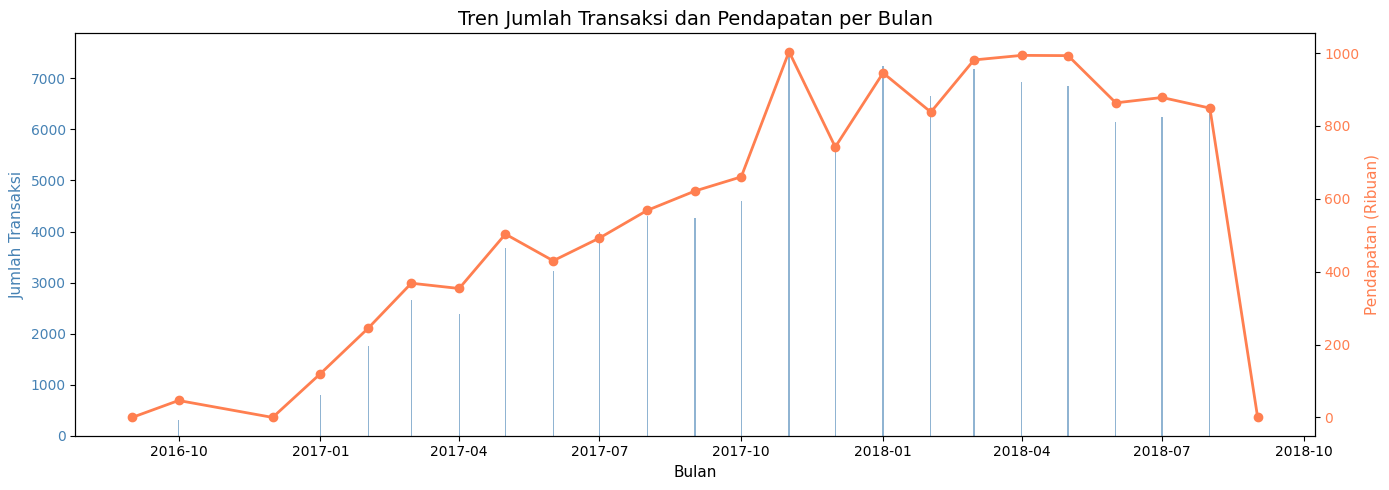


=== RINGKASAN TREN ===
Bulan dengan transaksi terbanyak: 2017-11 (7,507 transaksi)
Bulan dengan pendapatan tertinggi: 2017-11 (1,003,862)


In [13]:
# Menyiapkan data bulanan
df['bulan'] = df['order_purchase_timestamp'].dt.to_period('M')
bulanan = df.groupby('bulan').agg(
    transaksi=('order_id', 'nunique'),
    pendapatan=('price', 'sum')
).reset_index()
bulanan['tanggal'] = bulanan['bulan'].dt.to_timestamp()
bulanan['pendapatan_k'] = bulanan['pendapatan'] / 1000

# Plot Tren Jumlah Transaksi dan Pendapatan per Bulan
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(bulanan['tanggal'], bulanan['transaksi'], alpha=0.6, color='steelblue', label='Transaksi')
ax1.set_xlabel('Bulan', fontsize=11)
ax1.set_ylabel('Jumlah Transaksi', color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(bulanan['tanggal'], bulanan['pendapatan_k'], color='coral', marker='o', linewidth=2, label='Pendapatan')
ax2.set_ylabel('Pendapatan (Ribuan)', color='coral', fontsize=11)
ax2.tick_params(axis='y', labelcolor='coral')

plt.title('Tren Jumlah Transaksi dan Pendapatan per Bulan', fontsize=14)
fig.tight_layout()
plt.show()

# Tampilkan angka pertumbuhan
print("\n=== RINGKASAN TREN ===")
print(f"Bulan dengan transaksi terbanyak: {bulanan.loc[bulanan['transaksi'].idxmax(), 'bulan']} ({bulanan['transaksi'].max():,} transaksi)")
print(f"Bulan dengan pendapatan tertinggi: {bulanan.loc[bulanan['pendapatan'].idxmax(), 'bulan']} ({bulanan['pendapatan'].max():,.0f})")

**Insight:**
- Secara keseluruhan, terjadi peningkatan jumlah transaksi dan pendapatan dari waktu ke waktu, meskipun tidak selalu naik secara konsisten setiap bulan.
- Bulan November 2017 mencatatkan kinerja tertinggi untuk kedua metrik, yaitu 7.507 transaksi dengan total pendapatan mencapai 1.003.862. Bulan ini menjadi momen puncak dalam periode data yang dianalisis.
- Pada awal periode (September-Desember 2016), jumlah transaksi dan pendapatan masih sangat rendah, menunjukkan bahwa bisnis masih dalam tahap awal atau data yang tersedia masih terbatas.
- Terdapat beberapa bulan yang mengalami penurunan setelah mencapai puncak, yang mengindikasikan adanya sifat musiman atau faktor eksternal yang mempengaruhi aktivitas belanja.
- Jumlah transaksi dan pendapatan bergerak searah. Ketika transaksi naik, pendapatan juga ikut naik, dan sebaliknya. Hal ini menunjukkan bahwa peningkatan volume penjualan berdampak langsung pada peningkatan pendapatan.
- Pada akhir tahun 2018, terlihat kecenderungan penurunan dibandingkan puncaknya di November 2017, yang perlu diinvestigasi lebih lanjut penyebabnya.


### Pertanyaan 2: Kategori produk apa yang memberikan kontribusi pendapatan terbesar setiap bulan, dan bagaimana pola musiman penjualannya selama periode 2016–2018?



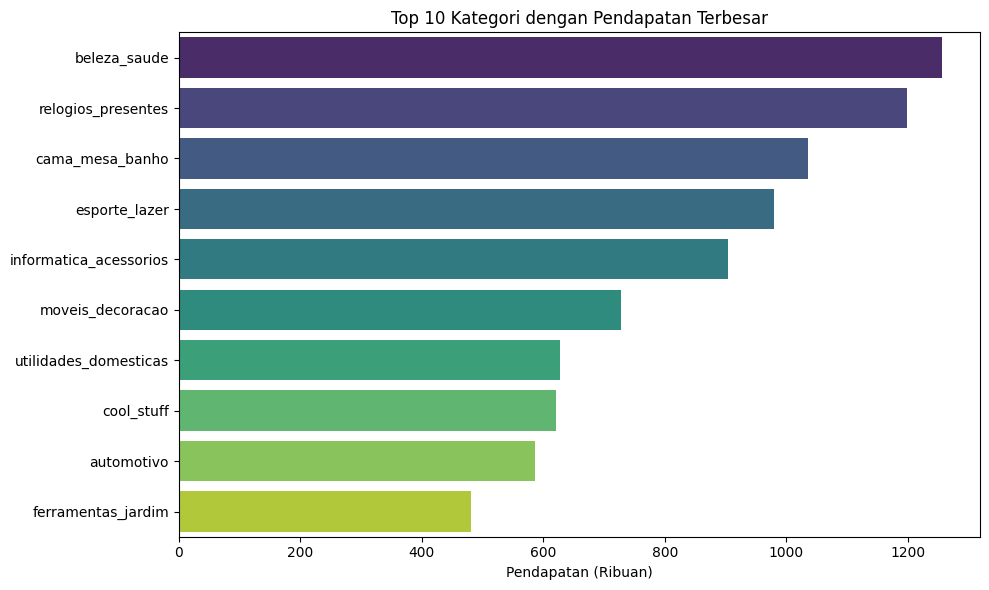

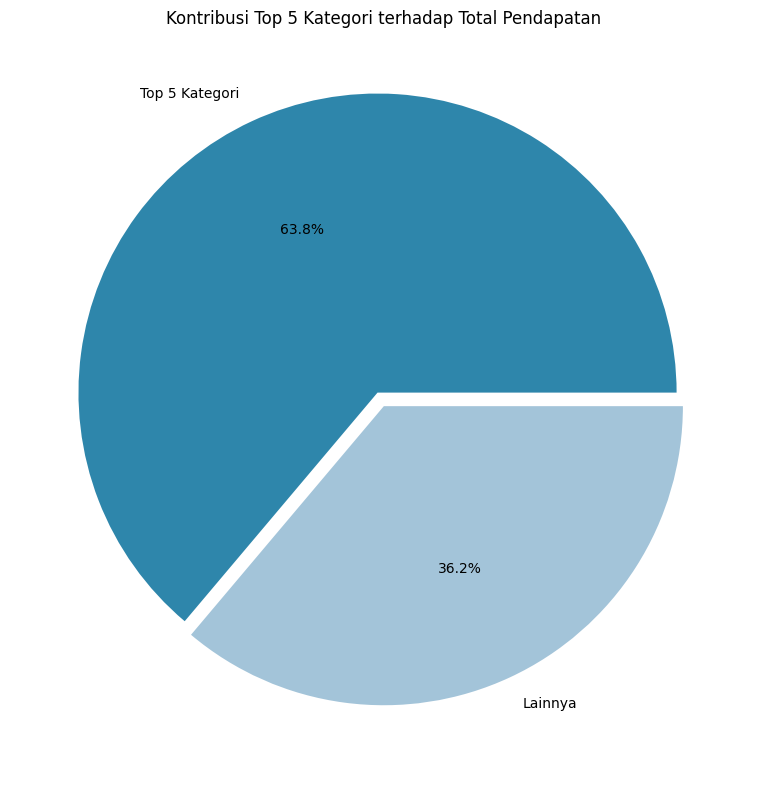

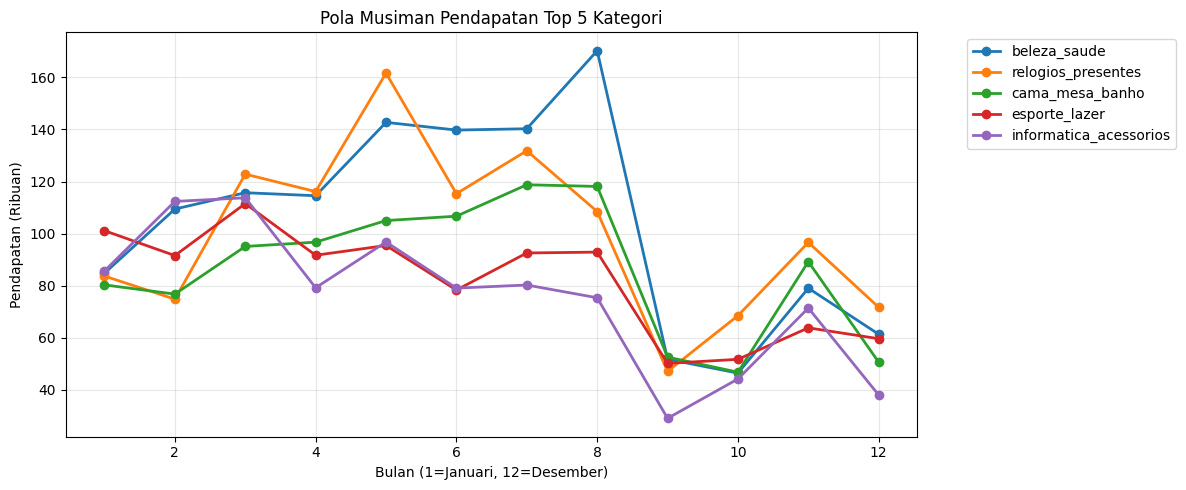


=== RINGKASAN KATEGORI ===
Top 5 kategori menyumbang: 63.8% dari total pendapatan
Kategori terbesar: beleza_saude dengan pendapatan 1256 (ribuan)


In [27]:
# Top 10 kategori berdasarkan pendapatan
pendapatan_kategori = df.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

# Buat dataframe top 10 kategori sebelum di plot
df_top10 = pendapatan_kategori.reset_index()
df_top10.columns = ['kategori', 'pendapatan']
df_top10['pendapatan_k'] = df_top10['pendapatan'] / 1000

# Plot menggunakan bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df_top10, y='kategori', x='pendapatan_k', hue='kategori', palette='viridis', legend=False)
plt.xlabel('Pendapatan (Ribuan)')
plt.ylabel('')
plt.title('Top 10 Kategori dengan Pendapatan Terbesar')
plt.tight_layout()
plt.show()

# Membuat pie chart untuk top 5 kategori vs lainnya
plt.figure(figsize=(8, 8))
top5 = pendapatan_kategori.head(5)
lainnya = pendapatan_kategori[5:].sum()
data_pie = [top5.sum(), lainnya]
labels_pie = ['Top 5 Kategori', 'Lainnya']
plt.pie(data_pie, labels=labels_pie, autopct='%1.1f%%', colors=['#2E86AB', '#A3C4D9'], explode=(0.05, 0))
plt.title('Kontribusi Top 5 Kategori terhadap Total Pendapatan')
plt.tight_layout()
plt.show()

# Pola musiman
top5_nama = pendapatan_kategori.head(5).index.tolist()

df_top5 = df[df['product_category_name'].isin(top5_nama)].copy()
df_top5['bulan'] = df_top5['order_purchase_timestamp'].dt.month

musiman = df_top5.groupby(['bulan', 'product_category_name'])['price'].sum().unstack().fillna(0) / 1000

plt.figure(figsize=(12, 5))
for kategori in top5_nama:
    plt.plot(musiman.index, musiman[kategori], marker='o', linewidth=2, label=kategori)

plt.xlabel('Bulan (1=Januari, 12=Desember)')
plt.ylabel('Pendapatan (Ribuan)')
plt.title('Pola Musiman Pendapatan Top 5 Kategori')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ringkasan
print("\n=== RINGKASAN KATEGORI ===")
print(f"Top 5 kategori menyumbang: {(top5.sum() / pendapatan_kategori.sum() * 100):.1f}% dari total pendapatan")
print(f"Kategori terbesar: {top5_nama[0]} dengan pendapatan {pendapatan_kategori.iloc[0]/1000:.0f} (ribuan)")

**Insight:**
- Kategori beleza_saude adalah kontributor pendapatan terbesar, menunjukkan loyalitas konsumen yang tinggi pada produk perawatan diri. Kategori relogios_presentes menyusul di posisi kedua, menandakan bahwa barang-barang dengan nilai per unit yang cenderung tinggi (seperti jam tangan) sangat diminati. Kategori cama_mesa_banho (perlengkapan tidur/mandi) melengkapi tiga besar, membuktikan bahwa kebutuhan dasar rumah tangga tetap menjadi penggerak ekonomi yang kuat.
- Meskipun masuk 10 besar, kategori ferramentas_jardim (alat kebun) memiliki pendapatan paling kecil, yang mungkin dipengaruhi oleh faktor musiman atau harga produk yang lebih rendah dibanding kategori lain.
- Top 5 kategori (beleza_saude, relogios_presentes, cama_mesa_banho, esporte_lazer, informatica_acessorios) menyumbang 63,8% dari total pendapatan, sementara sisanya 36,2% tersebar di kategori lainnya. Hal ini menunjukkan bahwa bisnis sangat bergantung pada beberapa kategori utama.
- Meskipun dari sisi volume transaksi kategori cama_mesa_banho adalah yang tertinggi, dari sisi pendapatan kategori ini hanya berada di peringkat ketiga. Sebaliknya, beleza_saude dan relogios_presentes memiliki pendapatan lebih tinggi meskipun volume transaksinya lebih rendah. Hal ini mengindikasikan bahwa produk-produk di kategori tersebut memiliki harga jual rata-rata yang lebih tinggi.
- Kategori beleza_saude dan cama_mesa_banho menunjukkan pendapatan yang relatif stabil sepanjang tahun. Sebagai produk kebutuhan sehari-hari (kecantikan dan perlengkapan rumah tangga), permintaan terhadap kategori ini cenderung tidak terpengaruh oleh musim atau momen tertentu.
- Kategori relogios_presentes (jam tangan & hadiah) menunjukkan peningkatan pendapatan yang terlihat pada bulan-bulan tertentu, kemungkinan besar terkait dengan momen pemberian hadiah seperti bulan Desember (Natal), bulan Februari (Valentine), atau bulan-bulan tertentu dengan tradisi pemberian kado.
- Kategori esporte_lazer (olahraga & rekreasi) dan informatica_acessorios (komputer & aksesoris) menunjukkan fluktuasi yang cukup terlihat, kemungkinan dipengaruhi oleh tren musiman, promo besar, atau peluncuran produk baru.


## Analisis Lanjutan (Opsional)

### Analisis Segmentasi Pelanggan dengan Metode RFM
RFM (Recency, Frequency, Monetary) adalah metode untuk mengukur dan mengelompokkan nilai pelanggan berdasarkan tiga faktor utama:
- Recency: Rentang waktu sejak transaksi terakhir pelanggan
- Frequency: Seberapa sering pelanggan melakukan transaksi  
- Monetary: Akumulasi nilai belanja pelanggan

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Bin_Monetary,Bin_Frequency
0,00012a2ce6f8dcda20d059ce98491703,293,1,89.80,2,1,3,213,Potential (Potensial),Basic,Sekali
1,000161a058600d5901f007fab4c27140,414,1,54.90,1,1,2,112,Lost (Hilang),Basic,Sekali
2,0001fd6190edaaf884bcaf3d49edf079,552,1,179.99,1,1,4,114,Lost (Hilang),Silver,Sekali
3,0002414f95344307404f0ace7a26f1d5,383,1,149.90,1,1,3,113,Lost (Hilang),Silver,Sekali
4,000379cdec625522490c315e70c7a9fb,154,1,93.00,3,1,3,313,Potential (Potensial),Basic,Sekali


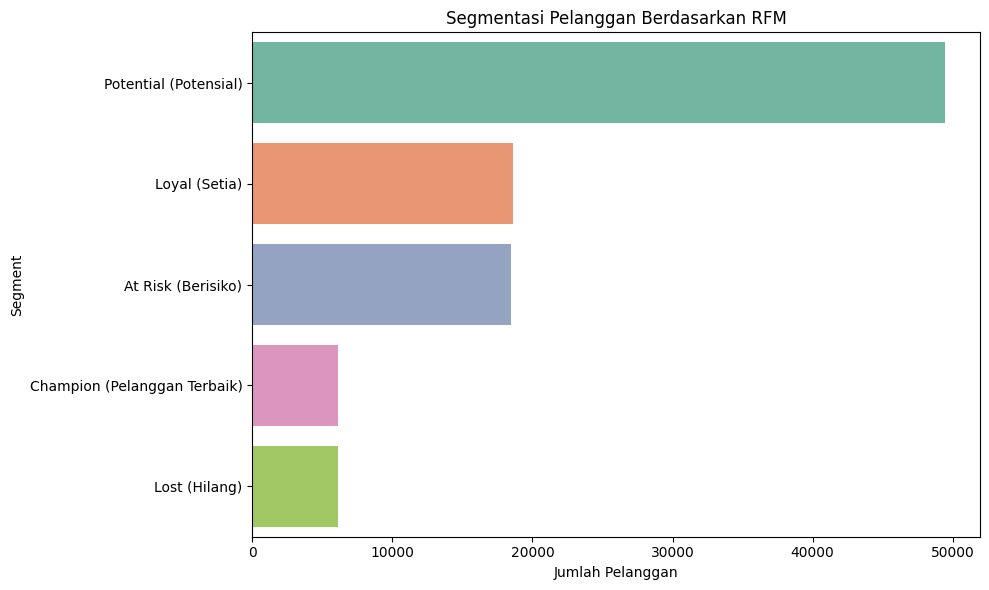


=== STATISTIK RFM PER SEGMEN ===


,Jumlah_Pelanggan,Rata_Recency,Rata_Frequency,Rata_Monetary,Total_Pendapatan
Segment,,,,,
Potential (Potensial),49467,202.772353,1.0,135.936247,6724358.34
Loyal (Setia),18613,138.673561,1.0,135.362313,2519498.74
At Risk (Berisiko),18496,460.952963,1.0,135.736593,2510584.03
Champion (Pelanggan Terbaik),6138,63.766373,1.0,144.950324,889705.09
Lost (Hilang),6102,459.895772,1.0,139.669326,852262.23


In [38]:
# Membuat skor 1-4 untuk setiap komponen
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=['4', '3', '2', '1'])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=['1', '2', '3', '4'])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=['1', '2', '3', '4'])

# Gabungkan skor
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
display(rfm.head())

# Segmentasi pelanggan
def segmentasi(row):
    if row['R_Score'] == '4' and row['F_Score'] == '4':
        return 'Champion (Pelanggan Terbaik)'
    elif row['R_Score'] in ['3','4'] and row['F_Score'] in ['3','4']:
        return 'Loyal (Setia)'
    elif row['R_Score'] == '1' and row['F_Score'] == '1':
        return 'Lost (Hilang)'
    elif row['R_Score'] == '1':
        return 'At Risk (Berisiko)'
    else:
        return 'Potential (Potensial)'

rfm['Segment'] = rfm.apply(segmentasi, axis=1)

# Bar chart jumlah pelanggan per segmen
plt.figure(figsize=(10,6))
segment_counts = rfm['Segment'].value_counts()
sns.barplot(y=segment_counts.index, x=segment_counts.values, hue=segment_counts.index, palette='Set2', legend=False)
plt.xlabel('Jumlah Pelanggan')
plt.title('Segmentasi Pelanggan Berdasarkan RFM')
plt.tight_layout()
plt.show()

# Statistik ringksan RFM
print("\n=== STATISTIK RFM PER SEGMEN ===")
display(rfm.groupby('Segment').agg(
    Jumlah_Pelanggan=('customer_id', 'count'),
    Rata_Recency=('Recency', 'mean'),
    Rata_Frequency=('Frequency', 'mean'),
    Rata_Monetary=('Monetary', 'mean'),
    Total_Pendapatan=('Monetary', 'sum')
).sort_values('Total_Pendapatan', ascending=False))

**Insight:**
1. Dominasi Pelanggan Potential (Potensial)
   
   Segmen ini adalah peluang terbesar untuk ditingkatkan menjadi loyal atau champion. Diperlukan strategi untuk mendorong pembelian kedua (repeat purchase). Segmen Potential mendominasi dengan 49.467 pelanggan dengan karakteristik:
   - Rata-rata Recency: 203 hari (sekitar 6-7 bulan tidak bertransaksi)
   - Rata-rata Frequency: 1 kali (belum ada pembelian ulang)
   - Total pendapatan: 6.724.358 (terbesar di antara semua segmen)
2. Loyal dan Champion
   - Champion (6.138 pelanggan): Rata-rata Recency terbaik (64 hari), Rata-rata Monetary tertinggi (145), artinya mereka aktif dan belanja tinggi.
   - Loyal (18.613 pelanggan): Rata-rata Recency cukup baik (139 hari), berpotensi naik ke Champion.
3. At Risk dan Lost (Pelanggan yang Terancam Hilang)
   - At Risk (18.496 pelanggan): Rata-rata Recency tinggi (461 hari = 1,2 tahun), artinya sudah sangat lama tidak bertransaksi.
   - Lost (6.102 pelanggan): Rata-rata Recency tinggi juga (460 hari).
4. Semua segmen memiliki rata-rata frequency = 1,0. Artinya, hampir seluruh pelanggan hanya bertransaksi satu kali dan tidak kembali. Tingkat retensi pelanggan sangat rendah. Untuk mengatasi hal tersebut bisa difokuskan pada program repeat purchase, seperti diskon untuk pembelian kedua, program poin atau cashback, ataupun email follow-up setelah pembelian pertama.



## Kategorisasi Pelanggan dengan Binning

Untuk mendapatkan gambaran lebih detail tentang profil pelanggan, dilakukan pengelompokan (binning) berdasarkan dua indikator:

- Total Pengeluaran (Monetary): Dibagi menjadi 4 kategori (Basic, Silver, Gold, Platinum)
- Frekuensi Pembelian (Frequency): Dibagi menjadi 3 kategori (Sekali, Beberapa Kali, Sering)


In [37]:
# Binning Monetary
rfm['Bin_Monetary'] = pd.cut(rfm['Monetary'],
                              bins=[0, 100, 250, 500, np.inf],
                              labels=['Basic', 'Silver', 'Gold', 'Platinum'])

# Binning Frequency
rfm['Bin_Frequency'] = pd.cut(rfm['Frequency'],
                               bins=[0, 1, 3, np.inf],
                               labels=['Sekali', 'Beberapa Kali', 'Sering'])

print("Hasil Binning:")
display(rfm[['customer_id', 'Monetary', 'Bin_Monetary', 'Frequency', 'Bin_Frequency']].head(10))

print("\nDistribusi Binning Monetary:")
print(rfm['Bin_Monetary'].value_counts())

print("\nDistribusi Binning Frequency:")
print(rfm['Bin_Frequency'].value_counts())

Hasil Binning:


,customer_id,Monetary,Bin_Monetary,Frequency,Bin_Frequency
0,00012a2ce6f8dcda20d059ce98491703,89.80,Basic,1,Sekali
1,000161a058600d5901f007fab4c27140,54.90,Basic,1,Sekali
2,0001fd6190edaaf884bcaf3d49edf079,179.99,Silver,1,Sekali
3,0002414f95344307404f0ace7a26f1d5,149.90,Silver,1,Sekali
4,000379cdec625522490c315e70c7a9fb,93.00,Basic,1,Sekali
5,0004164d20a9e969af783496f3408652,59.99,Basic,1,Sekali
6,000419c5494106c306a97b5635748086,34.30,Basic,1,Sekali
7,00046a560d407e99b969756e0b10f282,120.90,Silver,1,Sekali
8,00050bf6e01e69d5c0fd612f1bcfb69c,69.99,Basic,1,Sekali
9,000598caf2ef4117407665ac33275130,1107.00,Platinum,1,Sekali



Distribusi Binning Monetary:
Bin_Monetary
Basic       57590
Silver      29889
Gold         7145
Platinum     3581
Name: count, dtype: int64

Distribusi Binning Frequency:
Bin_Frequency
Sekali           98816
Beberapa Kali        0
Sering               0
Name: count, dtype: int64


**Insight**
1. Berdasarkan Tingkat Pengeluaran (Monetary):
   - Mayoritas pelanggan berada di kelas Basic sebanyak 57.590 pelanggan. Artinya, lebih dari setengah pelanggan memiliki total belanja di bawah 100.
   - Kelas Silver menempati posisi kedua dengan 29.889 pelanggan, diikuti Gold (7.145 pelanggan) dan Platinum (3.581 pelanggan).
   - Terdapat pelanggan dengan pengeluaran sangat tinggi (Platinum) seperti contoh pada baris terakhir (Monetary = 1107) meskipun hanya bertransaksi 1 kali.
2. Berdasarkan Frekuensi Pembelian (Frequency):
   - Seluruh 98.816 pelanggan (100%)** masuk kategori "Sekali" (hanya 1 kali transaksi). Tidak ada satupun pelanggan yang masuk kategori "Beberapa Kali" atau "Sering".
   - Tingkat repeat purchase = 0%. Artinya, tidak ada pelanggan yang melakukan pembelian lebih dari satu kali selama periode data.
3. Rekomendasi: Prioritas utama adalah mendorong repeat purchase karena seluruh pelanggan saat ini hanya bertransaksi sekali. Strategi yang dapat diterapkan meliputi program loyalitas, diskon untuk pembelian kedua, serta kampanye email follow-up. Dengan 57.590 pelanggan Basic, potensi pendapatan tambahan sangat besar tanpa perlu biaya akuisisi baru.

## Conclusion

- Conclution pertanyaan 1: Tren Jumlah Transaksi dan Pendapatan Selama Periode 2016–2018

Tren jumlah transaksi dan pendapatan menunjukkan peningkatan dari waktu ke waktu, meskipun terjadi fluktuasi di beberapa bulan. Puncak tertinggi untuk kedua metrik terjadi pada bulan November tahun 2017 dengan 7.507 transaksi dan total pendapatan sebesar 1.003.862. Pada awal periode (September-Oktober 2016), aktivitas transaksi masih sangat rendah, kemudian mulai meningkat signifikan pada Januari 2017. Secara umum, jumlah transaksi dan pendapatan bergerak searah, yang mengindikasikan bahwa peningkatan volume penjualan berdampak langsung pada peningkatan pendapatan.
- Conclution pertanyaan 2: Kategori Produk yang Memberikan Kontribusi Pendapatan Terbesar dan Pola Musimannya Selama Periode 2016–2018

Kategori beleza_saude (kecantikan & kesehatan) memberikan kontribusi pendapatan terbesar, diikuti oleh relogios_presentes (jam tangan & hadiah) dan cama_mesa_banho (perlengkapan rumah tangga). Top 5 kategori secara bersama-sama menyumbang 63,8% dari total pendapatan, sementara kategori lainnya hanya menyumbang 36,2%.

Dari sisi pola musiman, kategori beleza_saude dan cama_mesa_banho cenderung stabil sepanjang tahun karena merupakan produk kebutuhan sehari-hari. Sementara itu, kategori relogios_presentes menunjukkan peningkatan pada bulan-bulan tertentu yang berkaitan dengan momen pemberian hadiah.

In [42]:
df.to_csv('main_data.csv', index=False)